
##  Mémoire : Prédiction de la sinistralité automobile en assurance:  
### comparaison des modèles statistiques et des méthodes de Machine Learning

#### Objectif du mémoire
L’objectif de ce mémoire est d’analyser et de modéliser le **risque de sinistralité automobile** à partir de données d’assurance 

réelles , en vue de prédire la fréquence des sinistres par contrat:
 
Dans ce cadre, nous comparons les modèles statistiques traditionnels (régression linéaire, régression de Poisson), en particulier 

la régression de Poisson avec offset, aux méthodes de machine learning telles que les arbres de décision, les méthodes de boosting 

(régression, KNN, Random Forest, XGBoost) et, le cas échéant, les réseaux de neurones.


Cette comparaison vise à évaluer les performances prédictives de ces approches, ainsi que leurs avantages et limites en termes 

d’interprétabilité et d’applicabilité actuarielle, notamment pour la tarification des contrats, la prévention des sinistres et la 

gestion du risque.


Enfin, les principaux résultats et indicateurs de risque sont synthétisés à travers un tableau de bord interactif sous Power BI / 

Streamlit, permettant une visualisation des mesures clés (taux de sinistralité, sinistres moyens, bonus-malus moyen) et de la 

répartition géographique des sinistres.




## Pourquoi je fais ce mémoire ?


Prédire le nombre de sinistres constitue un enjeu central en assurance automobile, car il permet d’estimer la fréquence des 

sinistres associée à chaque contrat. Cette fréquence est un élément clé de la tarification, dans la mesure où elle conditionne 

directement le niveau de prime nécessaire pour couvrir le risque assuré. Une estimation fiable du nombre de sinistres attendus 

permet ainsi d’assurer une tarification plus équitable entre les assurés, tout en garantissant l’équilibre financier de l’assureur. 

Par ailleurs, la prédiction de la sinistralité contribue à une meilleure gestion du risque, en facilitant le calcul des provisions 

techniques et le respect des exigences réglementaires en matière de solvabilité. Enfin, l’identification des profils les plus 

exposés aux sinistres peut également servir à orienter des actions de prévention et à améliorer la maîtrise globale du risque.

#### Importation des bases de données freMTPL2freq 

In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
file=r"C:\Users\DELL\Desktop\S2\Mémoire PSA- GLM-ML\base de données mémoire\freMTPL2freq.csv"
df=pd.read_csv(file)

'pip' n'est pas reconnu en tant que commande interne
ou externe, un programme ex�cutable ou un fichier de commandes.


ModuleNotFoundError: No module named 'seaborn'

In [2]:
# Dataset shape and info
print("-"*50)
print("DATASET SHAPE")
print("-"*50)
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\n" + "-"*50)
print("DATA TYPES")
print("-"*50)
print(df.dtypes)
print("\n" + "-"*50)

# les noms des colonnes
print("COLUMN NAMES")
print("-"*50)
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(exclude=['object']).columns.tolist()

print("\n" + "-"*50)
print("VARIABLE TYPES")
print("-"*50)
print(f"Categorical ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical ({len(numerical_cols)}): {numerical_cols}")

--------------------------------------------------
DATASET SHAPE
--------------------------------------------------
Rows: 678013
Columns: 12

--------------------------------------------------
DATA TYPES
--------------------------------------------------
IDpol         float64
ClaimNb         int64
Exposure      float64
VehPower        int64
VehAge          int64
DrivAge         int64
BonusMalus      int64
VehBrand       object
VehGas         object
Area           object
Density         int64
Region         object
dtype: object

--------------------------------------------------
COLUMN NAMES
--------------------------------------------------
1. IDpol
2. ClaimNb
3. Exposure
4. VehPower
5. VehAge
6. DrivAge
7. BonusMalus
8. VehBrand
9. VehGas
10. Area
11. Density
12. Region

--------------------------------------------------
VARIABLE TYPES
--------------------------------------------------
Categorical (4): ['VehBrand', 'VehGas', 'Area', 'Region']
Numerical (8): ['IDpol', 'ClaimNb', 'Expos

In [3]:
#Les premières lignes du dataset
print("-"*50)
print("Les premières lignes du dataset")
print("-"*50)
display(df.head(3))
print("-"*50)
#Les dernières lignes du dataset
print("Les dernières lignes du dataset")
print("-"*50)
display(df.tail(3))
print("-"*50)
#Les valeurs manquantes
print("Les valeurs manquantes")
print("\n" + "-"*50)
print(df.isnull().sum())
#les valeur dupliquées
print("-"*50)
print("Les valeurs dupliquées")
print("\n" + "-"*50)
print(f"Nombre de lignes dupliquées: {df.duplicated().sum()}")

--------------------------------------------------
Les premières lignes du dataset
--------------------------------------------------


,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region
0,1.0,1,0.10,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
1,3.0,1,0.77,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
2,5.0,1,0.75,6,2,52,50,B12,Diesel,B,54,Picardie


--------------------------------------------------
Les dernières lignes du dataset
--------------------------------------------------


,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region
678010,6114328.0,0,0.00274,6,2,45,50,B12,Diesel,D,1323,Rhone-Alpes
678011,6114329.0,0,0.00274,4,0,60,50,B12,Regular,B,95,Bourgogne
678012,6114330.0,0,0.00274,7,6,29,54,B12,Diesel,B,65,Aquitaine


--------------------------------------------------
Les valeurs manquantes

--------------------------------------------------
IDpol         0
ClaimNb       0
Exposure      0
VehPower      0
VehAge        0
DrivAge       0
BonusMalus    0
VehBrand      0
VehGas        0
Area          0
Density       0
Region        0
dtype: int64
--------------------------------------------------
Les valeurs dupliquées

--------------------------------------------------
Nombre de lignes dupliquées: 0


In [4]:
#le détecteur de valeurs aberrantes
print("="*100)
print("La détection des valeurs aberrantes")
print("="*100)
print("-"*100)
print("1. IDpol: numéro de police (identifiant unique)")
print("-"*100)
print("2. ClaimNb: nombre de sinistres sur la police donnée")
print(f"Les valeur pour chaque modalité: {df['ClaimNb'].value_counts()}")
print("possibilité de garder que les 4 premières modalités pour éviter les valeurs aberrantes")
print("-"*100)
print("3. Exposure: exposition totale en unités annuelles (entre 0 et 1)")
print(f"le minimum est {df['Exposure'].min()}, le maximum est {df['Exposure'].max()}")
print(f"il y a {(df['Exposure'] > 1).sum()} observations avec Exposure > 1")
print("-"*100)
print("4. Area: code de zone (catégoriel, ordinal)")
print(f"Les valeur pour chaque modalité: {df['Area'].value_counts()}")
print("-"*100)
print("5. VehPower: puissance du véhicule (catégoriel, ordinal)")
print(f"Les valeur pour chaque modalité: {df['VehPower'].value_counts()}")
print("-"*100)
print("6. VehAge: âge du véhicule en années")
print(f"le minimum est {df['VehAge'].min()}, le maximum est {df['VehAge'].max()}")
print("-"*100)
print("7. DrivAge: âge du conducteur (le plus fréquent) en années")
print(f"le minimum est {df['DrivAge'].min()}, le maximum est {df['DrivAge'].max()}")
print(f"il y a {(df['DrivAge'] < 18).sum()} observations avec DrivAge < 18")
print("-"*100)
print("8. BonusMalus: niveau de bonus-malus compris entre 50 et 230 (niveau de référence 100)")
print(f"le minimum est {df['BonusMalus'].min()}, le maximum est {df['BonusMalus'].max()}")
print(f"il y a {(df['BonusMalus'] < 50).sum()} observations avec BonusMalus < 50")
print(f"il y a {(df['BonusMalus'] > 230).sum()} observations avec BonusMalus > 230")
print("-"*100)
print("9. VehBrand: marque du véhicule (catégoriel, nominal)")
print(f"Les valeur pour chaque modalité: {df['VehBrand'].value_counts()}")
print("-"*100)
print("10. VehGas: type de carburant du véhicule (diesel ou essence) (binaire)")
print(f"le nombre de modalités est:{df['VehGas'].value_counts()}")
print("-"*100)
print("11. Density: densité d’habitants par km² dans la ville de résidence du conducteur")
print(f"le minimum est {df['Density'].min()}, le maximum est {df['Density'].max()}")
print(f"il y a {(df['Density'] < 0).sum()} observations avec Density < 0")
print(f"il y a {(df['Density'] > 10000).sum()} observations avec Density > 10000")

print("-"*100)
print("12. Region: régions de France (avant 2016), illustrées à la Figure 1 (catégoriel)")
print(f"Les valeur pour chaque modalité: {df['Region'].value_counts().sort_values}")
print("-"*100)



La détection des valeurs aberrantes
----------------------------------------------------------------------------------------------------
1. IDpol: numéro de police (identifiant unique)
----------------------------------------------------------------------------------------------------
2. ClaimNb: nombre de sinistres sur la police donnée
Les valeur pour chaque modalité: ClaimNb
0     643953
1      32178
2       1784
3         82
4          7
11         3
5          2
6          1
8          1
16         1
9          1
Name: count, dtype: int64
possibilité de garder que les 4 premières modalités pour éviter les valeurs aberrantes
----------------------------------------------------------------------------------------------------
3. Exposure: exposition totale en unités annuelles (entre 0 et 1)
le minimum est 0.00273224, le maximum est 2.01
il y a 1224 observations avec Exposure > 1
----------------------------------------------------------------------------------------------------
4. Are

In [5]:
df.describe()

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density
count,6.780130e+05,678013.000000,678013.000000,678013.000000,678013.000000,678013.000000,678013.000000,678013.000000
mean,2.621857e+06,0.053247,0.528750,6.454631,7.044265,45.499122,59.761502,1792.422405
std,1.641783e+06,0.240117,0.364442,2.050906,5.666232,14.137444,15.636658,3958.646564
min,1.000000e+00,0.000000,0.002732,4.000000,0.000000,18.000000,50.000000,1.000000
25%,1.157951e+06,0.000000,0.180000,5.000000,2.000000,34.000000,50.000000,92.000000
50%,2.272152e+06,0.000000,0.490000,6.000000,6.000000,44.000000,50.000000,393.000000
75%,4.046274e+06,0.000000,0.990000,7.000000,11.000000,55.000000,64.000000,1658.000000
max,6.114330e+06,16.000000,2.010000,15.000000,100.000000,100.000000,230.000000,27000.000000


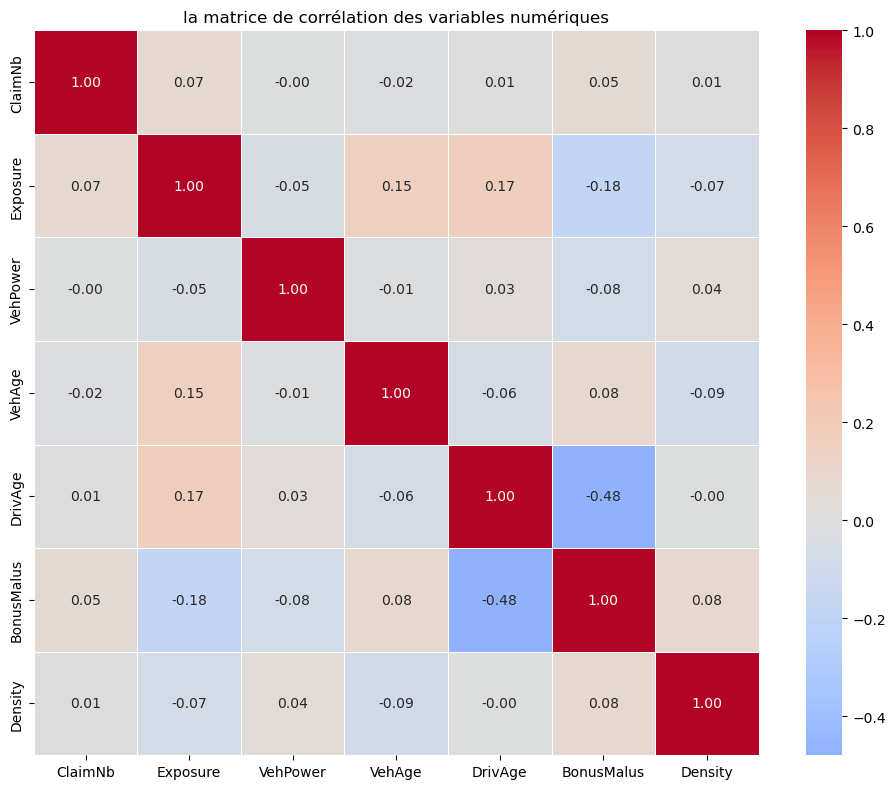

ClaimNb       1.000000
Exposure      0.068909
BonusMalus    0.050544
DrivAge       0.011392
Density       0.010754
VehPower     -0.004259
VehAge       -0.021768
Name: ClaimNb, dtype: float64


In [6]:
#heat map 
plt.figure(figsize=(10,8))
    
correlation=df.drop(columns=['IDpol']).corr(numeric_only=True)
plt.title('la matrice de corrélation des variables numériques')
sns.heatmap(correlation,annot=True, cmap='coolwarm', center=0, square=True, fmt='.2f', linewidths=0.5)
plt.tight_layout()
plt.show()
corr_with_claimnb = df.drop(columns=['IDpol']).corr(numeric_only=True)["ClaimNb"].sort_values(ascending=False)
print(corr_with_claimnb)

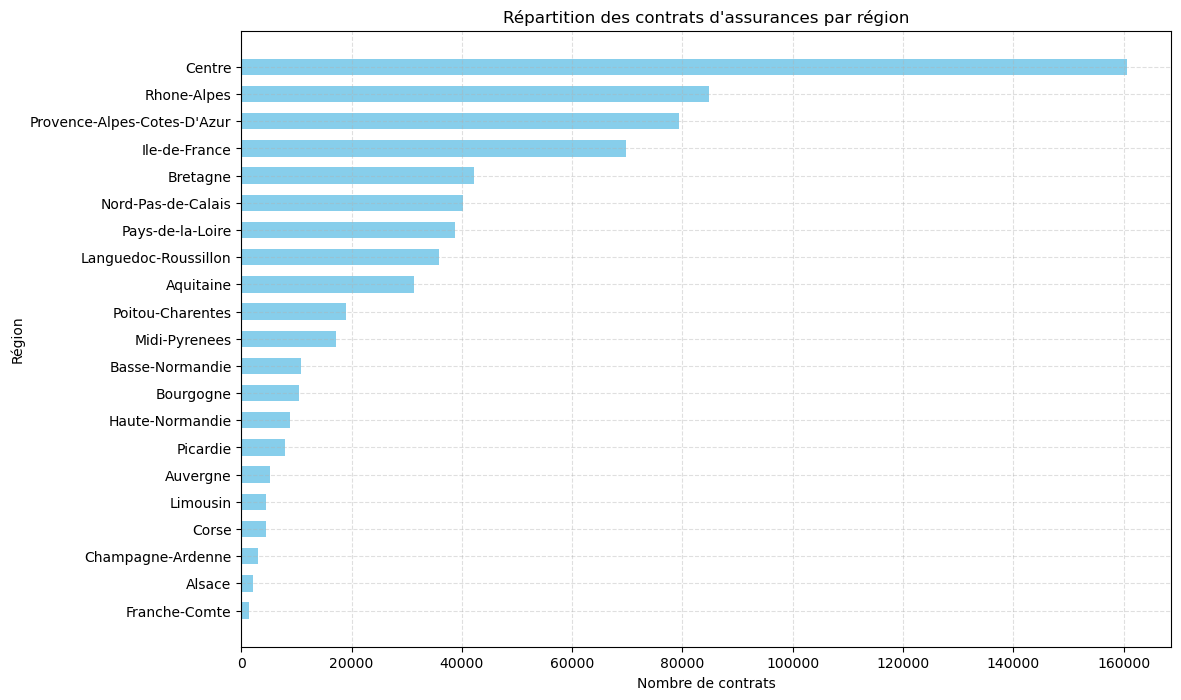

In [12]:
region_counts = df['Region'].value_counts()

plt.figure(figsize=(12,8))  # this is  for the size of the graph 
plt.barh(region_counts.index, region_counts.values, color='skyblue', height=0.6)  # height < 1 pour espacer
plt.ylabel("Région")
plt.xlabel("Nombre de contrats")
plt.title("Répartition des contrats d'assurances par région")
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.gca().invert_yaxis()  # optionnel : met la région la plus fréquente en haut
plt.show()

ClaimNb
0     643953
1      32178
2       1784
3         82
4          7
11         3
5          2
6          1
8          1
16         1
9          1
Name: count, dtype: int64


C:\Users\lenovo\AppData\Local\Temp\ipykernel_8536\4056014787.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='ClaimNb', data=df, palette='viridis')


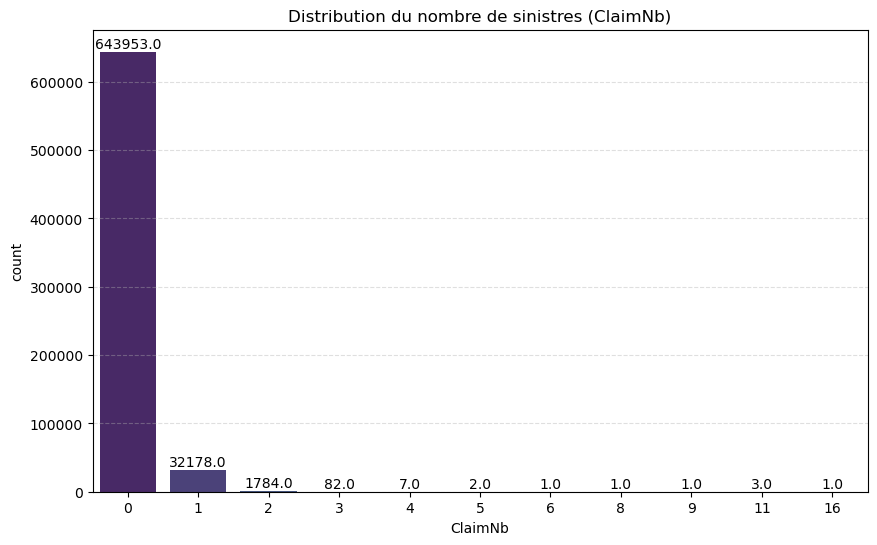

In [23]:
print(df["ClaimNb"].value_counts())
#un graph countplot pour la variable "ClainNb" avec des grilles pour mieux visualiser les différentes modalités
plt.figure(figsize=(10,6))
sns.countplot(x='ClaimNb', data=df, palette='viridis')
plt.title("Distribution du nombre de sinistres (ClaimNb)")
plt.grid(axis='y', linestyle='--', alpha=0.4)
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points') 
plt.show()

In [8]:
#features engineering
# créer une variable qui prend la valeur 1 si le conducteur a eu un accident (ClaimNb > 0) et 0 sinon
# afin d'utiliser la régression logistique comme un modèle de classification de départ 
df['HadAccident'] = (df['ClaimNb'] > 0).astype(int)
# l'utilisation de la méthode du one hot encoding pour les variables catégorielles
df_encoded = pd.get_dummies(
    df,
    columns=['Region', 'Area', 'VehGas', 'VehBrand'],
    drop_first=True
)
# Affichage des premières lignes du nouveau DataFrame
display(df_encoded.head(3))
print("-"*50)

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density,HadAccident,Region_Aquitaine,...,VehBrand_B10,VehBrand_B11,VehBrand_B12,VehBrand_B13,VehBrand_B14,VehBrand_B2,VehBrand_B3,VehBrand_B4,VehBrand_B5,VehBrand_B6
0,1.0,1,0.10,5,0,55,50,1217,1,False,...,False,False,True,False,False,False,False,False,False,False
1,3.0,1,0.77,5,0,55,50,1217,1,False,...,False,False,True,False,False,False,False,False,False,False
2,5.0,1,0.75,6,2,52,50,54,1,False,...,False,False,True,False,False,False,False,False,False,False


--------------------------------------------------


In [9]:
# création du modèlz de machine learning pour la classification binaire
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
#importation des metrics pour évaluer le modèle
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report  
#séparation des données en variables explicatives et variable cible
X = df_encoded.drop(['IDpol', 'ClaimNb', 'HadAccident'], axis=1)
y = df_encoded['HadAccident']
# le modèle de régression logistique
regressor=LogisticRegression(max_iter=1000)
#le max_iter=1000 est utilisé pour augmenter le nombre maximum d'itérations que l'algorithme de régression logistique peut effectuer avant de s'arrêter. 
# Cela peut être nécessaire si le modèle ne converge pas dans le nombre d'itérations par défaut (100). En augmentant max_iter,
# on donne plus de chances à l'algorithme de trouver une solution optimale, surtout si les données sont complexes ou si le taux d'apprentissage est faible.

# séparation des données en un ensemble d'entraînement et un ensemble de test
#le random_state=42 est utilisé souvent pour garantir la reproductibilité des résultats. 
# En fixant une valeur spécifique pour random_state, 
# on s'assure que les mêmes données seront utilisées pour l'entraînement et le test à chaque exécution du code, 
# ce qui facilite la comparaison des performances du modèle et le débogage.
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
# entraînement du modèle
regressor.fit(X_train,y_train)
# prédiction sur l'ensemble de test
y_pred=regressor.predict(X_test)
# évaluation du modèle
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.4f}")
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.4f}")
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.4f}")
conf_matrix = confusion_matrix(y_test, y_pred)
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(conf_matrix)




c:\Users\lenovo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.9495
Precision: 1.0000
Recall: 0.0003
F1 Score: 0.0006
Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97    128757
           1       1.00      0.00      0.00      6846

    accuracy                           0.95    135603
   macro avg       0.97      0.50      0.49    135603
weighted avg       0.95      0.95      0.92    135603

Confusion Matrix:
[[128757      0]
 [  6844      2]]


##  Analyse des performances du modèle

### **ACCURACY**
Sur 100 prédictions, environ 95 sont correctes.  
Mais le dataset est **très déséquilibré (~95 % de classe 0)** :

- Classe 0 : 128 757  
- Classe 1 : 6 846  

Donc, si mon modèle prédit presque toujours 0, il aura déjà **~95 % d’accuracy**.  
L’accuracy est donc **trompeuse dans un contexte de classes déséquilibrées**.

---

### **PRECISION**
La précision répond à la question :  
**Parmi toutes les prédictions "1", combien sont vraiment des 1 ?**

Dans notre cas :  
Chaque fois que mon modèle a dit "1", il avait raison.

Mais le problème est que :
- Il n’a dit "1" que **2 fois**
- Alors qu’on a **6 846 "1" dans le test set**

Le modèle **ne prend pas de risque** et prédit presque toujours 0.

---

### **RECALL**
Le recall répond à la question :  
**Parmi tous les vrais "1", combien le modèle arrive-t-il à détecter ?**

Ici :

Recall ≈ 0.0003  
Cela signifie que le modèle a détecté **2 / 6 846**.

Donc le modèle **ne détecte pratiquement rien** de la classe 1.

---

### **F1-SCORE**
Le F1-score est important car il mesure l’équilibre entre **PRECISION** et **RECALL**.

Dans notre cas :  
F1-score classe 1 = **0.00**

Cela signifie que le modèle est **inutile pour détecter la classe 1**,  
même si la précision est parfaite.

---

### **CONFUSION MATRIX**

Le modèle est un "héros" de prédiction de la classe 0 :

- Sur **128 757 observations de 0**, il a prédit **128 757 "0"**
- Sur **6 846 observations de 1**, il n’a prédit que **2 "1"**

Le modèle généralise donc fortement la modalité **"0"**.

---

##  Questions / Réflexion

- Le modèle **généralise-t-il trop la modalité "0"** ?
- Est-ce que la méthode de réduction des "0" (**undersampling**) dans la data d’entraînement pourrait rééquilibrer le modèle ?
- Faut-il passer à un **GLM de comptage** avec une régression sur la variable *ClaimNb* ?
- Tester un **Binomiale négative** serait-il plus adapté ?
- Tester un **Binomiale négative**,**ZIP = Zero-Inflated Poisson**, **ZINB = Zero-Inflated Negative Binomial** serait-il plus adapté ?
- Tester un **XGBoost** serait-il plus adapté ?
- Mais dans ce cas, est-ce que **l’interprétabilité du modèle** poserait un problème ?


La methode cross validation 

courbe de rouck
